**PCA and k-means clustering on returns**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fbourgey/fre-gy-7773-mlfe/blob/main/08_pca_k_means_returns_solution.ipynb)

# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import yfinance as yf
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234

# Market data

In [3]:
# list of tickers (US large-cap stocks from S&P 500)
TICKERS = (
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "GOOGL",
    "META",
    "ORCL",
    "CRM",
    "ADBE",
    "AMD",
    "JPM",
    "BAC",
    "WFC",
    "GS",
    "MS",
    "C",
    "BLK",
    "AXP",
    "SCHW",
    "USB",
    "JNJ",
    "PFE",
    "MRK",
    "ABBV",
    "LLY",
    "UNH",
    "TMO",
    "DHR",
    "BMY",
    "AMGN",
    "XOM",
    "CVX",
    "COP",
    "SLB",
    "EOG",
    "CAT",
    "DE",
    "UNP",
    "GE",
    "HON",
    "WMT",
    "COST",
    "HD",
    "MCD",
    "SBUX",
    "NKE",
    "DIS",
    "NFLX",
    "KO",
    "PEP",
    "T",
    "VZ",
    "CMCSA",
    "INTC",
    "QCOM",
    "IBM",
    "BA",
    "RTX",
    "NEE",
    "DUK",
)

In [4]:
# load tickers info from file or fetch from yfinance if not available
try:
    df_tickers = pd.read_csv("data/tickers.csv").set_index("ticker")
except FileNotFoundError:
    print("tickers.csv not found, fetching data from yfinance...")
    rows = []
    for t in TICKERS:
        info = yf.Ticker(t).info
        rows.append(
            {"ticker": t, "name": info.get("shortName"), "sector": info.get("sector")}
        )

    _df_tickers = pd.DataFrame(rows).sort_values("sector")
    df_tickers = _df_tickers.sort_values("ticker").set_index("ticker")
    # save for future use
    _df_tickers.sort_values("ticker").reset_index(drop=True).to_csv(
        "data/tickers.csv", index=False
    )
except Exception as e:
    print(f"Error loading tickers.csv: {e}")
    raise

In [5]:
df_tickers.head()

,name,sector
ticker,,
AAPL,Apple Inc.,Technology
ABBV,AbbVie Inc.,Healthcare
ADBE,Adobe Inc.,Technology
AMD,"Advanced Micro Devices, Inc.",Technology
AMGN,Amgen Inc.,Healthcare


In [6]:
# load prices from file or fetch from yfinance if not available
start = "2021-01-01"
end = "2026-01-01"

try:
    df_prices = pd.read_csv("data/prices.csv", index_col="Date")
except FileNotFoundError:
    print("prices.csv not found, fetching data from yfinance...")
    prices = yf.download(
        TICKERS, start=start, end=end, auto_adjust=True, progress=False
    )["Close"]
    df_prices = prices
    # save for future use
    prices.reset_index().to_csv("data/prices.csv", index=False)
except Exception as e:
    print(f"Error loading prices.csv: {e}")
    raise

In [7]:
df_prices.head()

,AAPL,ABBV,ADBE,AMD,AMGN,AMZN,AXP,BA,BAC,BLK,...,SLB,T,TMO,UNH,UNP,USB,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,125.856712,86.047379,485.339996,92.300003,192.309921,159.331497,110.722672,202.720001,26.464052,626.998108,...,19.601675,15.702639,465.205017,319.662140,180.571716,36.844452,42.871235,26.340195,45.541061,33.693794
2021-01-05,127.412788,86.937164,485.690002,92.769997,193.243210,160.925507,111.313599,211.630005,26.666731,630.314636,...,20.655432,15.606633,471.022278,315.363403,182.786514,36.964291,42.674553,27.076303,45.298634,35.317581
2021-01-06,123.123863,86.186165,466.309998,90.330002,197.901245,156.919006,115.431458,211.029999,28.332306,648.291565,...,21.798492,15.910659,478.407227,328.598022,186.611237,39.153229,43.191772,28.991949,45.581463,36.218796
2021-01-07,127.325226,87.108589,477.739990,95.160004,198.554535,158.108002,114.518410,212.710007,28.957994,661.928406,...,22.218208,15.953326,493.315216,333.866364,189.208481,39.936138,43.094582,29.648237,45.578342,36.502949
2021-01-08,128.424194,87.565727,485.100006,94.580002,202.347122,159.134995,114.631378,209.899994,28.667175,667.247192,...,22.182491,15.843309,505.117493,332.366272,194.634262,39.400887,42.557095,29.435385,45.572132,36.908909


In [8]:
# clean data and compute returns

# drop names with missing data
df_prices = df_prices.dropna()

# daily log returns
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

print(df_returns.shape)
df_returns.head()

(1254, 60)


,AAPL,ABBV,ADBE,AMD,AMGN,AMZN,AXP,BA,BAC,BLK,...,SLB,T,TMO,UNH,UNP,USB,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.012288,0.010288,0.000721,0.005079,0.004841,0.009955,0.005323,0.043014,0.007629,0.005276,...,0.052363,-0.006133,0.012427,-0.013539,0.012191,0.003247,-0.004598,0.027563,-0.005337,0.047067
2021-01-06,-0.034241,-0.008676,-0.040720,-0.026654,0.023819,-0.025212,0.036325,-0.002839,0.060586,0.028121,...,0.053862,0.019293,0.015557,0.041110,0.020709,0.057531,0.012047,0.068359,0.006224,0.025197
2021-01-07,0.033554,0.010646,0.024216,0.052090,0.003296,0.007549,-0.007941,0.007929,0.021844,0.020817,...,0.019071,0.002678,0.030686,0.015906,0.013822,0.019799,-0.002253,0.022384,-0.000068,0.007815
2021-01-08,0.008594,0.005234,0.015288,-0.006114,0.018921,0.006475,0.000986,-0.013299,-0.010094,0.008003,...,-0.001609,-0.006920,0.023643,-0.004503,0.028273,-0.013493,-0.012551,-0.007205,-0.000136,0.011060
2021-01-11,-0.023523,0.016182,-0.022642,0.027839,-0.003865,-0.021754,-0.005930,-0.014927,0.016464,0.013433,...,0.006020,-0.005182,0.002048,-0.007291,-0.006741,0.000405,-0.005900,0.001506,0.004491,0.029905


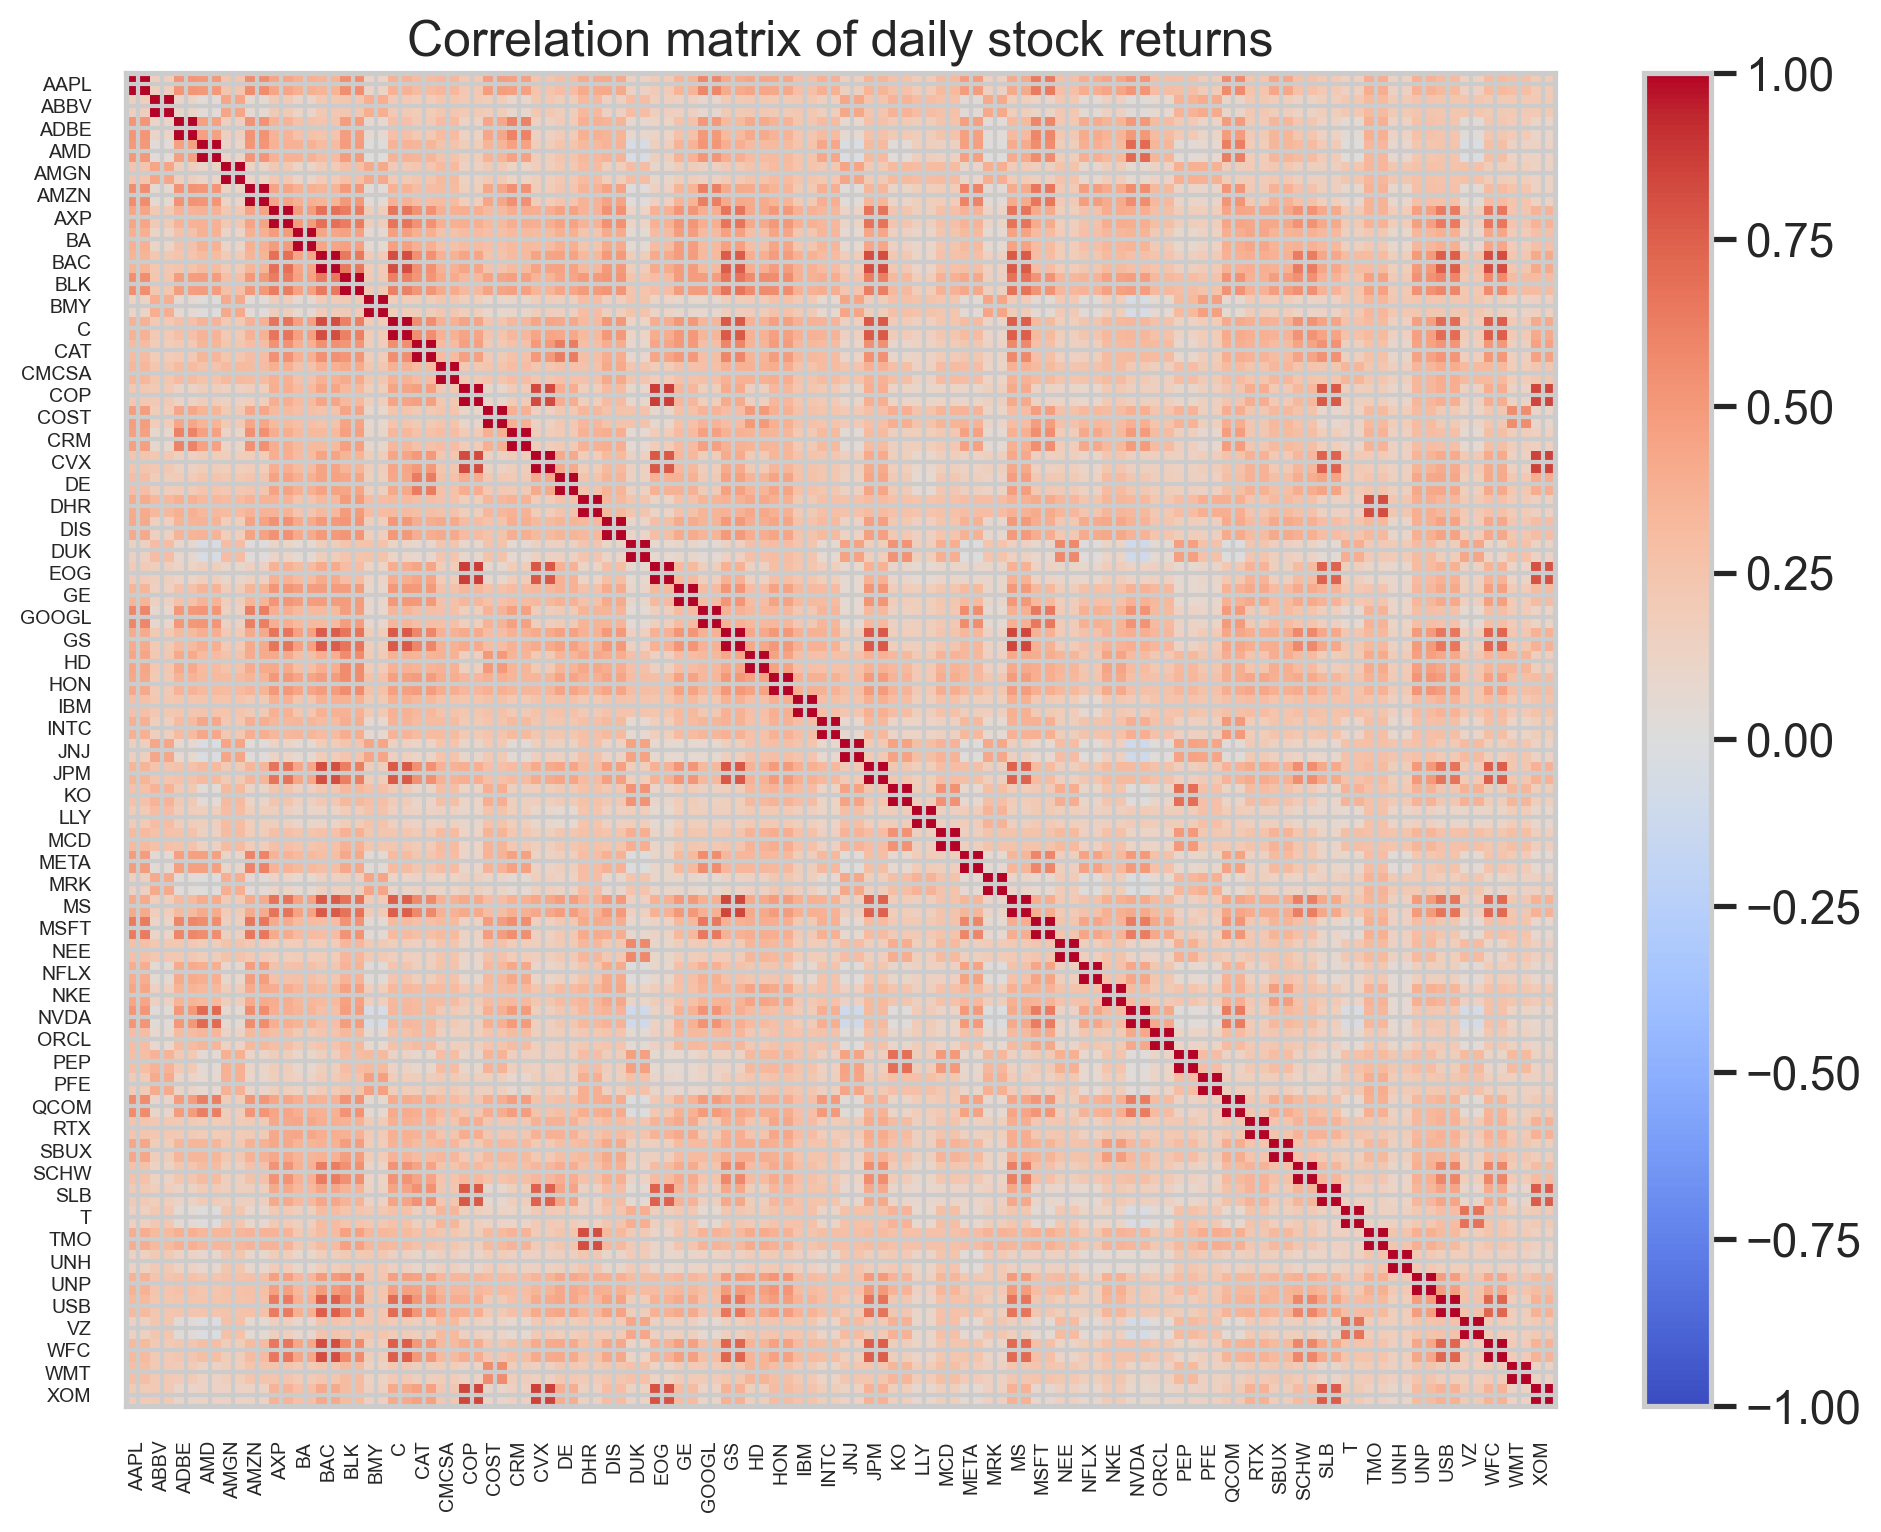

In [41]:
# quick look at correlation matrix of returns
df_corr = df_returns.corr()

plt.figure(figsize=(10, 8))
plt.imshow(df_corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.title("Correlation matrix of daily stock returns")
plt.xticks(range(len(df_corr.columns)), df_corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(df_corr.index)), df_corr.index, fontsize=7)
plt.tight_layout()
plt.show()

In [11]:
df_returns.shape

(1254, 60)

In [12]:
# PCA on returns

# a useful choice here is to standardize each stock first, so PCA is driven by the
# correlation structure rather than raw volatility differences.

scaler = StandardScaler(with_mean=True, with_std=True)
X = scaler.fit_transform(df_returns)  # shape: (T, N)

k = 10
pca = PCA(n_components=k)
pca.fit(X)

explained = pca.explained_variance_ratio_
component_weights = pca.components_.T  # shape: (N, 10)
loadings = component_weights * np.sqrt(pca.explained_variance_)

In [14]:
# sanity check with svd

U_x, S_x, Vt_x = np.linalg.svd(X, full_matrices=True)

# PCA components are the right singular vectors (up to sign), eigenvalues are related
# to singular values, and the reconstruction is consistent with inverse transform
assert np.allclose(np.abs(Vt_x.T[:, :k]), np.abs(pca.components_.T))

# eigenvalues are related to singular values by $\lambda_i = \sigma_i^2 / (n-1)$
assert np.allclose(S_x[:k] ** 2 / (X.shape[0] - 1), pca.explained_variance_)

# explained variance ratio is consistent with singular values
assert np.allclose(pca.explained_variance_ratio_, S_x[:k] ** 2 / np.sum(S_x**2))

# reconstruction from svd is consistent with PCA inverse transform
assert np.allclose(
    (U_x[:, :k] * S_x[:k]) @ Vt_x[:k, :], pca.inverse_transform(pca.transform(X))
)

In [15]:
Vt_x.T[3, :k]

array([-0.12917734,  0.22320993, -0.05203553,  0.08914121,  0.05257584,
       -0.04449785, -0.0488267 ,  0.18426522, -0.06360983, -0.05051457])

In [16]:
pca.components_.T[3, :k]

array([ 0.12917734,  0.22320993, -0.05203553,  0.08914121,  0.05257584,
        0.04449785,  0.0488267 ,  0.18426522, -0.06360983,  0.05051457])

- $X = U \Sigma V^T$ with singular values $\sigma_1 \geq \sigma_2 \geq ... \geq \sigma_p$ where $p = min(n, d)$

- PCA eigenvalues are $\lambda_i = \sigma_i^2 / (n-1)$

- explained variance ratio of the $i$-th component is $\lambda_i / \sum_{j=1}^p \lambda_j = \frac{\sigma_i^2 / (n-1)}{\sum_{j=1}^p \sigma_j^2 / (n-1)} = \frac{\sigma_i^2}{\sum_{j=1}^p \sigma_j^2}$

**Factor-model interpretation of PCA**

After standardizing returns, PCA gives an approximate factor model for the standardized return vector $x_t \in \mathbb{R}^N$:

$$
x_t \approx W f_t,
$$

where:

- $W \in \mathbb{R}^{N \times K}$ contains the PCA directions across stocks.
- $f_t \in \mathbb{R}^K$ is the vector of PCA factor scores at date $t$.

In the notebook, `component_weights = pca.components_.T` is exactly the matrix $W$. Each column is one principal direction, and each entry measures how strongly a stock contributes to that component.

A common related object is the PCA loading matrix:

$$
L = W \Lambda^{1/2},
$$

where $\Lambda = \operatorname{diag}(\lambda_1, \ldots, \lambda_K)$ contains the PCA eigenvalues. In code, this is the `loadings` matrix:

```python
loadings = component_weights * np.sqrt(pca.explained_variance_)
```

So the distinction is:

- `component_weights[:, j]`: direction of principal component $j$.
- `loadings[:, j]`: the same direction rescaled by the standard deviation explained by component $j$.

In this notebook we use `loadings` when interpreting factors and plotting stocks in PCA loading space, and we use `component_weights` for K-means because we want the clustering to depend on direction rather than on the extra variance scaling.

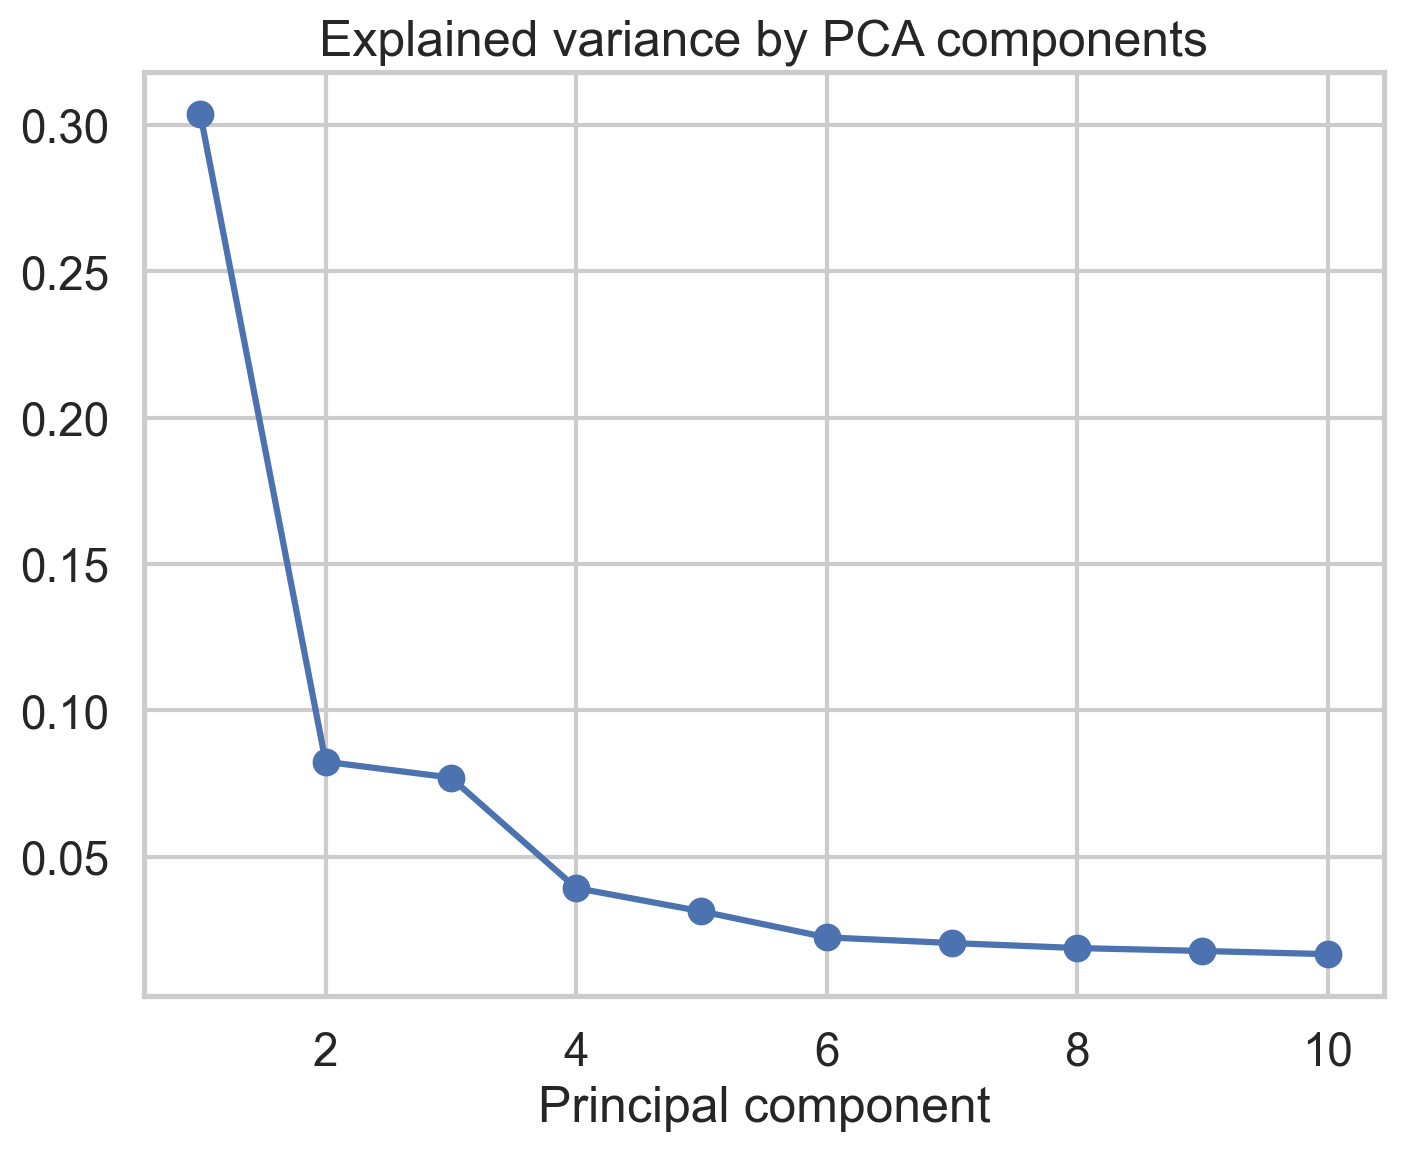

In [44]:
# explained variance plot

plt.figure()
plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
plt.xlabel("Principal component")
plt.title("Explained variance by PCA components")
plt.grid(True)
plt.show()

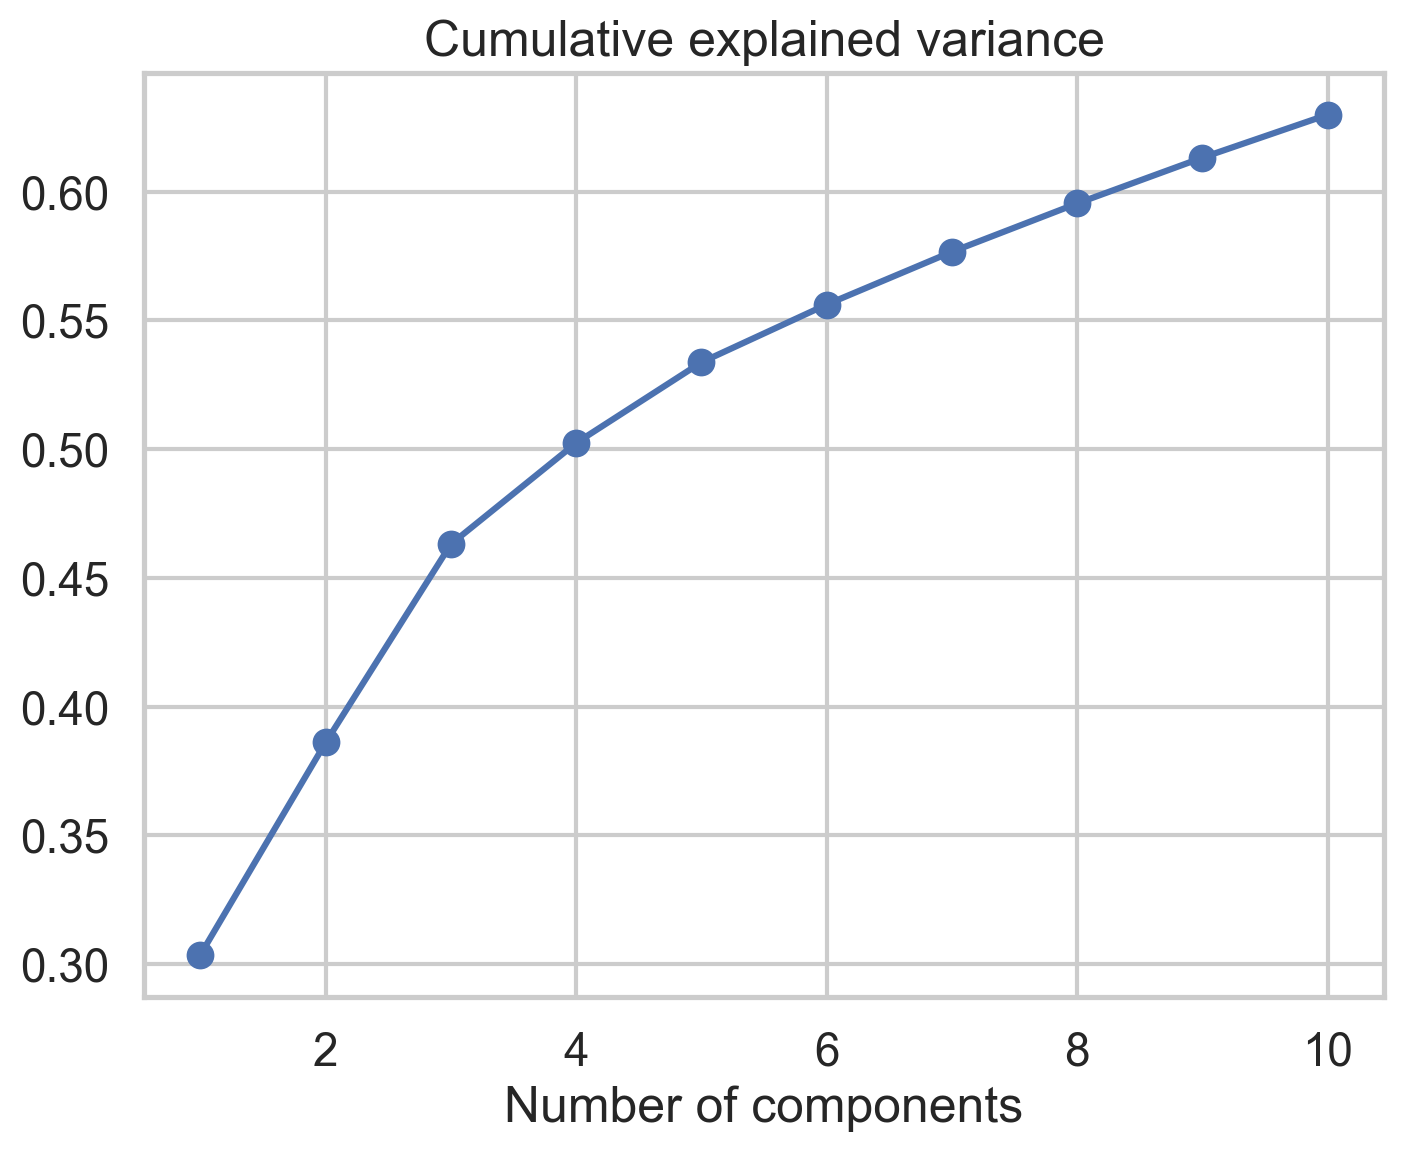

In [45]:
# cumulative explained variance plot
plt.figure()
plt.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker="o")
plt.xlabel("Number of components")
plt.title("Cumulative explained variance")
plt.grid(True)
plt.show()

In [46]:
# inspect the first factor
# for equities, PC1 is often close to a "market factor" with positive loadings across
# most stocks, while PC2 and PC3 may show sector or style patterns.

pc1 = pd.Series(loadings[:, 0], index=df_returns.columns).sort_values()
pc2 = pd.Series(loadings[:, 1], index=df_returns.columns).sort_values()
pc3 = pd.Series(loadings[:, 2], index=df_returns.columns).sort_values()

print("PC1 loadings:")
print(pc1)

print("\nPC2 loadings:")
print(pc2)

print("\nPC3 loadings:")
print(pc3)

PC1 loadings:
UNH      0.269635
MRK      0.279747
LLY      0.296686
DUK      0.306694
BMY      0.315497
VZ       0.320265
JNJ      0.321231
PFE      0.347710
T        0.348252
ABBV     0.355480
PEP      0.382309
WMT      0.384398
AMGN     0.390353
NEE      0.394561
ORCL     0.413393
NFLX     0.416808
KO       0.422056
MCD      0.463506
EOG      0.479439
IBM      0.492941
XOM      0.493112
INTC     0.503206
META     0.508743
SLB      0.520559
COST     0.523504
COP      0.524017
RTX      0.527098
CMCSA    0.536728
NVDA     0.537928
ADBE     0.539516
CVX      0.545407
NKE      0.551481
AMD      0.551641
TMO      0.556892
CRM      0.559634
SBUX     0.563732
GOOGL    0.565238
DHR      0.568679
DE       0.570780
BA       0.578358
AMZN     0.599694
MSFT     0.603515
SCHW     0.607738
GE       0.613006
HD       0.615941
QCOM     0.626663
UNP      0.639201
DIS      0.644607
AAPL     0.649769
CAT      0.654638
WFC      0.695531
HON      0.700177
USB      0.703420
JPM      0.746613
C        0.752

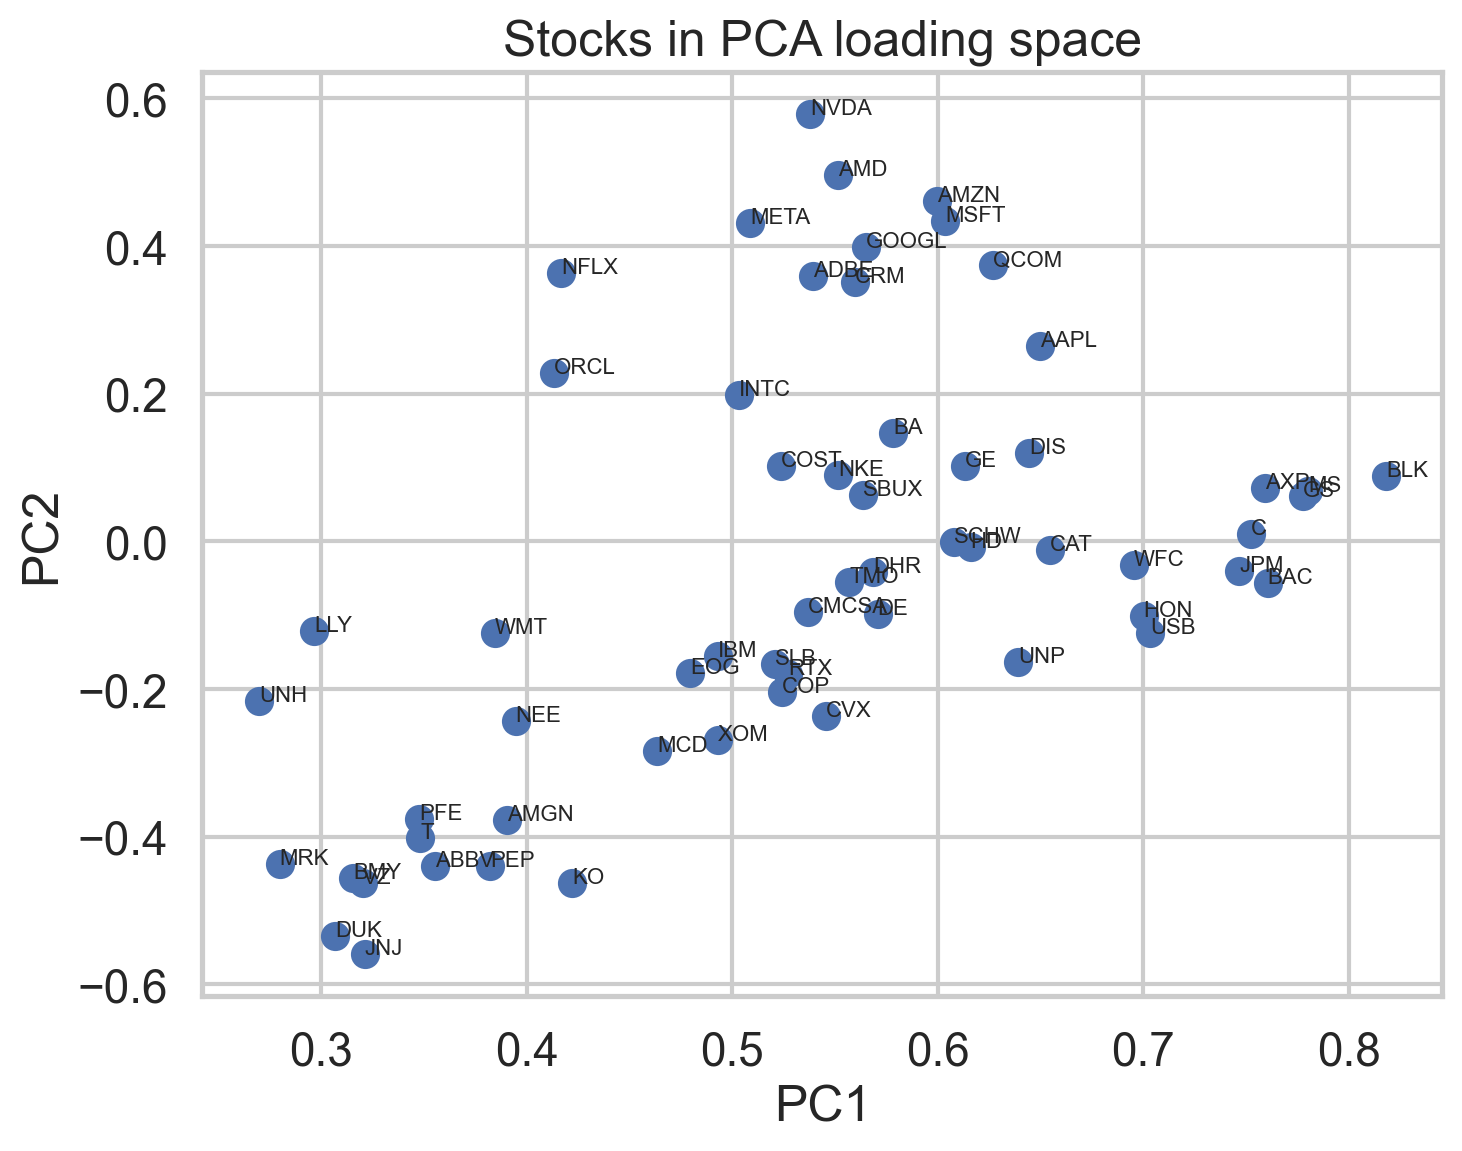

In [47]:
# scatter plot in PCA loading space

plt.figure(figsize=(8, 6))
plt.scatter(loadings[:, 0], loadings[:, 1])

for i, ticker in enumerate(df_returns.columns):
    plt.text(loadings[i, 0], loadings[i, 1], ticker, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Stocks in PCA loading space")
plt.grid(True)
plt.show()

In [48]:
# often:
# PC1: broad market exposure
# PC2 / PC3: sector or style splits
# higher PCs: more idiosyncratic structure

Selected k=3 from silhouette scores on the first 3 PCA component weights.


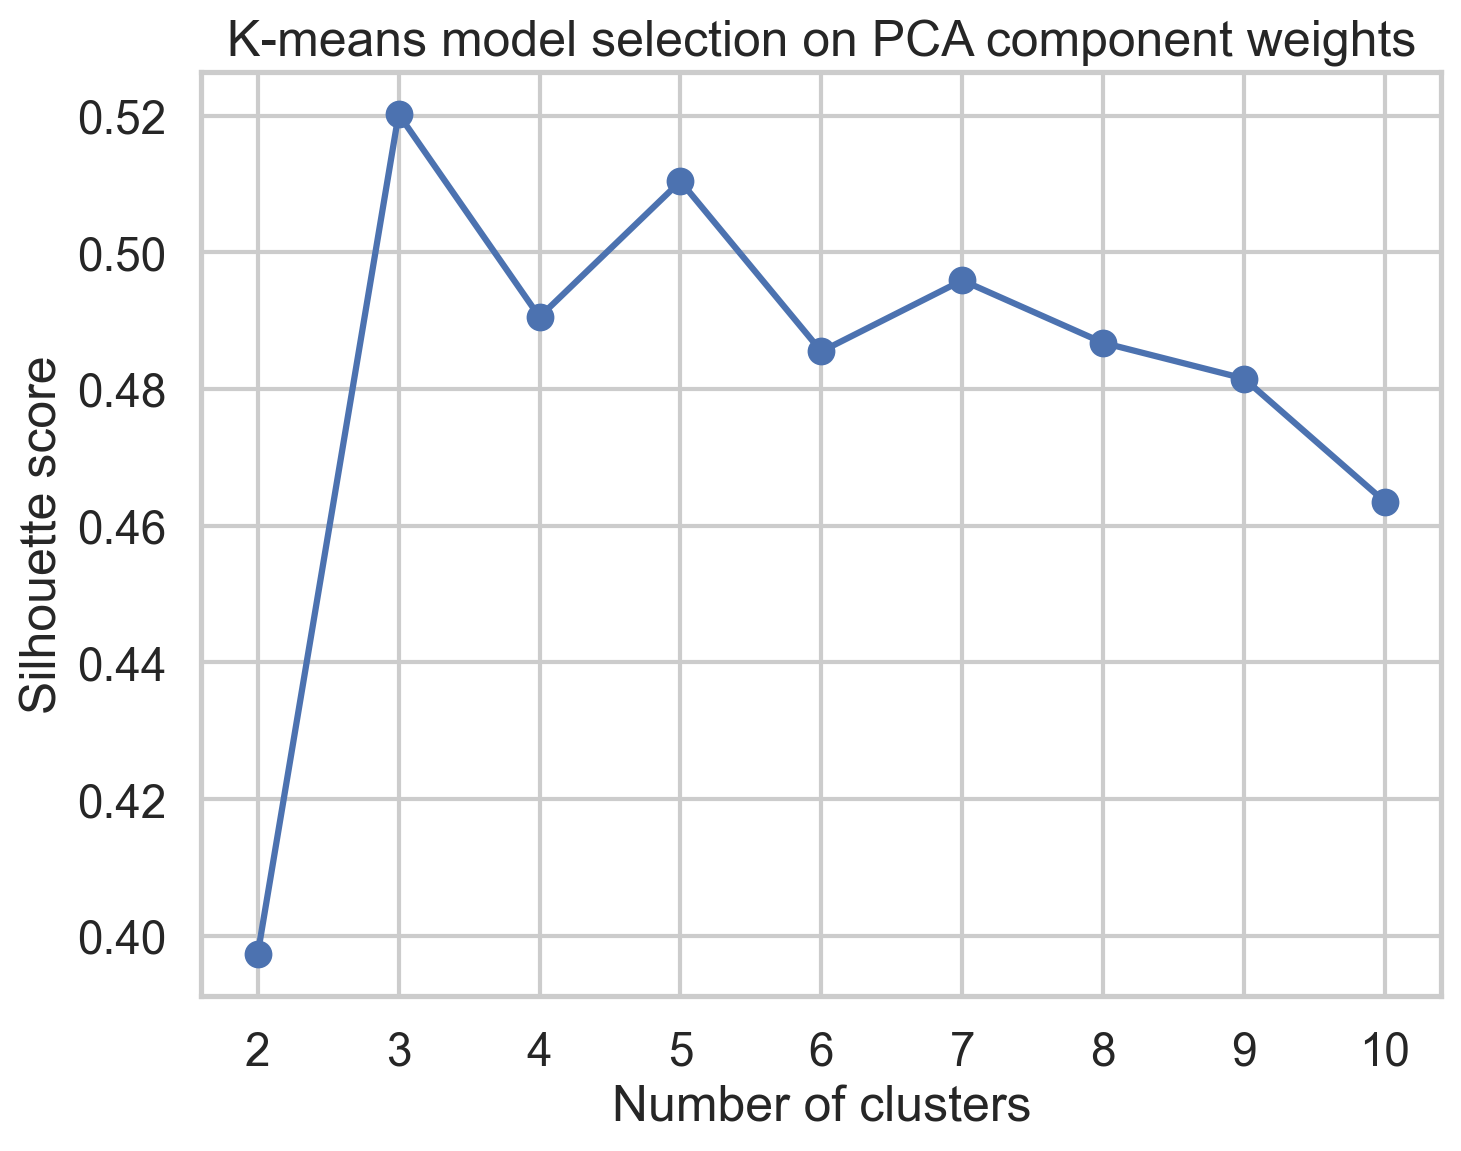

,ticker,cluster,pc1,pc2,pc3
6,AXP,0,0.177831,0.032777,0.089641
7,BA,0,0.135434,0.066285,0.063707
8,BAC,0,0.178093,-0.025432,0.153485
11,C,0,0.176168,0.004402,0.149290
12,CAT,0,0.153296,-0.005482,0.158033


In [49]:
Z = component_weights[:, :3]  # use the first 3 component weights as clustering features

k_grid = np.arange(2, 11)
silhouette_scores = np.array(
    [
        silhouette_score(
            Z,
            KMeans(n_clusters=k, random_state=SEED, n_init=20).fit_predict(Z),
        )
        for k in k_grid
    ]
)

n_clusters = int(k_grid[silhouette_scores.argmax()])
print(
    f"Selected k={n_clusters} from silhouette scores on the first 3 PCA component "
    "weights."
)

plt.figure()
plt.plot(k_grid, silhouette_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("K-means model selection on PCA component weights")
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20)
labels = kmeans.fit_predict(Z)

clusters = pd.DataFrame(
    {
        "ticker": df_returns.columns,
        "cluster": labels,
        "pc1": component_weights[:, 0],
        "pc2": component_weights[:, 1],
        "pc3": component_weights[:, 2],
    }
).sort_values(["cluster", "ticker"])

clusters.head()

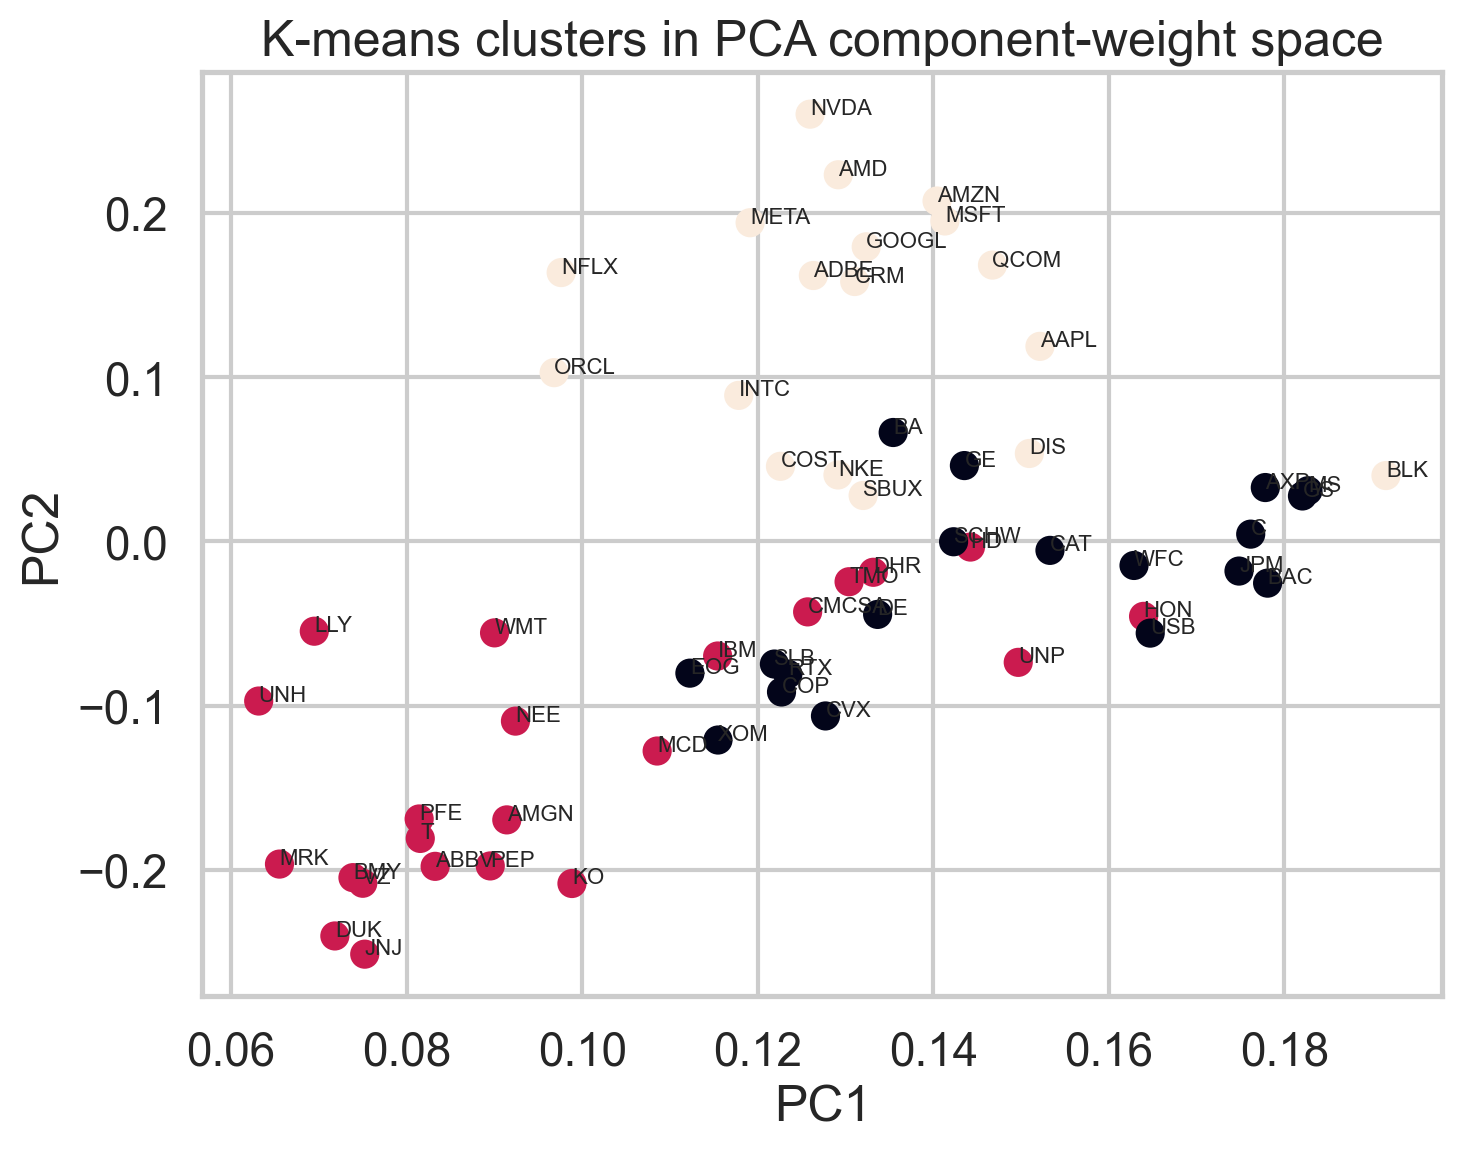

In [50]:
# plot clusters in PCA component-weight space
plt.figure()
scatter = plt.scatter(component_weights[:, 0], component_weights[:, 1], c=labels)

for i, ticker in enumerate(df_returns.columns):
    plt.text(component_weights[i, 0], component_weights[i, 1], ticker, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clusters in PCA component-weight space")
plt.grid(True)
plt.show()

In [51]:
# print stocks by cluster
for k in range(n_clusters):
    names = clusters.loc[clusters["cluster"] == k, "ticker"].tolist()
    print(f"Cluster {k}: {names}")

Cluster 0: ['AXP', 'BA', 'BAC', 'C', 'CAT', 'COP', 'CVX', 'DE', 'EOG', 'GE', 'GS', 'JPM', 'MS', 'RTX', 'SCHW', 'SLB', 'USB', 'WFC', 'XOM']
Cluster 1: ['ABBV', 'AMGN', 'BMY', 'CMCSA', 'DHR', 'DUK', 'HD', 'HON', 'IBM', 'JNJ', 'KO', 'LLY', 'MCD', 'MRK', 'NEE', 'PEP', 'PFE', 'T', 'TMO', 'UNH', 'UNP', 'VZ', 'WMT']
Cluster 2: ['AAPL', 'ADBE', 'AMD', 'AMZN', 'BLK', 'COST', 'CRM', 'DIS', 'GOOGL', 'INTC', 'META', 'MSFT', 'NFLX', 'NKE', 'NVDA', 'ORCL', 'QCOM', 'SBUX']


In [52]:
df_clusters_new = clusters.sort_values("ticker").set_index("ticker")

In [53]:
df_all = pd.concat([df_tickers, df_clusters_new], axis=1).sort_values("cluster")
df_all.head()

,name,sector,cluster,pc1,pc2,pc3
ticker,,,,,,
XOM,Exxon Mobil Corporation,Energy,0,0.115472,-0.120946,0.248328
CVX,Chevron Corporation,Energy,0,0.127718,-0.106291,0.230133
EOG,"EOG Resources, Inc.",Energy,0,0.112270,-0.080237,0.257958
COP,ConocoPhillips,Energy,0,0.122709,-0.091692,0.255731
GS,"Goldman Sachs Group, Inc. (The)",Financial Services,0,0.182065,0.027645,0.123909


In [54]:
# group by cluster and sector to see if clusters correspond to sectors
df_all.groupby("cluster")["sector"].value_counts()

cluster  sector                
0        Financial Services         9
         Energy                     5
         Industrials                5
1        Healthcare                10
         Communication Services     3
         Consumer Defensive         3
         Consumer Cyclical          2
         Industrials                2
         Utilities                  2
         Technology                 1
2        Technology                 9
         Communication Services     4
         Consumer Cyclical          3
         Consumer Defensive         1
         Financial Services         1
Name: count, dtype: int64

In [55]:
# often clusters will correspond to intuitive groupings of stocks, e.g.:
# tech / semis
# banks / financials
# healthcare
# energy
# defensive consumer / utilities

# But K-means is only a similarity grouping, not a structural factor model.

In [56]:
# cluster on correlations directly
corr_features = df_returns.corr().values
kmeans_corr = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20)
labels_corr = kmeans_corr.fit_predict(corr_features)

clusters_corr = pd.DataFrame(
    {"ticker": df_returns.columns, "cluster": labels_corr}
).sort_values(["cluster", "ticker"])

df_clusters_corr = clusters_corr.sort_values("ticker").set_index("ticker")
df_clusters_corr.head()

,cluster
ticker,
AAPL,0
ABBV,2
ADBE,0
AMD,0
AMGN,2


In [57]:
df_corr_new = pd.concat([df_clusters_corr, df_tickers], axis=1).sort_values("cluster")
df_corr_new.groupby("cluster")["sector"].value_counts()

cluster  sector                
0        Technology                 9
         Communication Services     4
         Consumer Cyclical          4
         Healthcare                 2
         Consumer Defensive         1
1        Financial Services        10
         Industrials                7
         Energy                     5
         Communication Services     1
         Technology                 1
2        Healthcare                 8
         Consumer Defensive         3
         Communication Services     2
         Utilities                  2
         Consumer Cyclical          1
Name: count, dtype: int64

Takeaway:

- PCA extracts a few dominant co-movement directions.

- In stock returns, PC1 is often market-like.

- PC2 and PC3 often reflect sector/style structure.

- The cluster count is selected here with a silhouette scan on the first 3 PCA component weights.

- K-means groups stocks into similar buckets, but does not produce factor exposures.